# SDG&E Hosting Capacity Calculations

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box, MultiLineString

In [2]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [3]:
# set option to see all data frame columns
pd.set_option('display.max_columns', None)

In [62]:
# Read in circuits
circuits_raw = gpd.read_file("../../../../../../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson").to_crs("EPSG:4326")

In [71]:
circuits_raw.head(2)

,LINE_SEGMENT_NUMBER,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,1,221.0,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (-116.43681 32.97732, -116.43681 32..."
1,21,211.0,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (-116.52521 33.22100, -116.52521 33..."


In [63]:
# Read in customer usage data
feeder = pd.read_csv("../../../../../../../capstone/electrigrid/data/utilities/sandiego_grid/sdge-customer-data.csv")

In [49]:
feeder.head()

,CIRCUIT_NAME,residential_customer_percentage,commercial_customer_percentage,industrial_customer_percentage,agriculture_customer_percentage
0,972,83,17,0,0
1,971,87,13,0,0
2,240,75,24,0,0
3,1138,95,5,0,0
4,244,91,9,0,0


In [9]:
# circuits_raw = circuits_raw[['FeederId', 'CSV_LineSe','LoadCapaci', 'GenCapacit', 'GenericPVC', 'GenCapac_1', 'GenericCap', 'geometry']]
# circuits_raw.head(2)

,FeederId,CSV_LineSe,LoadCapaci,GenCapacit,GenericPVC,GenCapac_1,GenericCap,geometry
0,062541102,3862041,0.00,0.00000,0.00,0.00,0.00,"LINESTRING (-121.95921 39.12370, -121.95951 39..."
1,043302102,5458148,2.38,0.00006,0.07,2.44,2.44,"LINESTRING (-122.73809 38.48070, -122.73809 38..."


## Join customer percentages to circuits

In [65]:
# some data standardization
feeder['circuit_name'] = feeder['circuit_name'].astype('float')
feeder = feeder.rename(columns = {'circuit_name':'CIRCUIT_NAME'})
circuits_raw['CIRCUIT_NAME'] = circuits_raw['CIRCUIT_NAME'].astype('float')

In [86]:
# Use circuit name to join
circuits = circuits_raw.merge(feeder, how = "left", on = "CIRCUIT_NAME")

### Check spatial distribution of circuits we have customer data on

In [87]:
# make binary column to denote which circuits have data
circuits['CIRCUIT_NAME'] = circuits['CIRCUIT_NAME'].astype('object')

<Axes: >

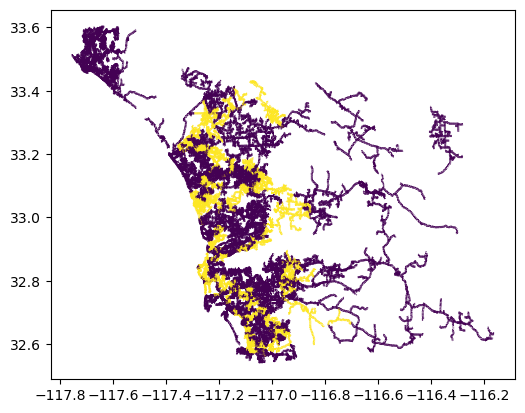

In [68]:
circuits.plot(column = 'cust_data')

Distribution could be better...will manually go ahead and add data where it is missing.

### Join based on nearest distance

To complete this, the observations *with* customer breakdown data will have to be extracted, and then the variables will be assigned through a join.

In [88]:
# Reproject to projected crs (for nearest join)
circuits = circuits.to_crs("EPSG:3310")

In [76]:
# Keep only rows with customer data
circuits_cust_data = circuits[circuits['cust_data'] == 1]

In [92]:
feeder.columns

Index(['CIRCUIT_NAME', 'residential_customer_percentage',
       'commercial_customer_percentage', 'industrial_customer_percentage',
       'agriculture_customer_percentage'],
      dtype='object')

In [94]:
# drop custumer columns before join
cols = feeder.columns
circuits = circuits.drop(cols, axis = 1)

In [95]:
# Join nearest
circuits_linked = gpd.sjoin_nearest(circuits, 
                                        circuits_cust_data, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [96]:
circuits_linked.head(3)

,LINE_SEGMENT_NUMBER__left,SUBID__left,ICAWOF_UNIGENERATION__left,ICAWOF_UNILOAD__left,ICAWNOF_UNIGENERATION__left,ICAWNOF_UNILOAD__left,OBJECTID__left,VOLTAGE__left,ICAWOF_PVGENERATION__left,OHUG__left,LABELTEXT__left,ICAWNOF_PVGENERATION__left,LABELTEXT_ICA__left,RESTRICTED__left,ICAWOF_UNIGENERATION_LC__left,ICAWOF_UNILOAD_LC__left,ICAWNOF_UNIGENERATION_LC__left,geometry,index__right,LINE_SEGMENT_NUMBER__right,CIRCUIT_NAME,SUBID__right,ICAWOF_UNIGENERATION__right,ICAWOF_UNILOAD__right,ICAWNOF_UNIGENERATION__right,ICAWNOF_UNILOAD__right,OBJECTID__right,VOLTAGE__right,ICAWOF_PVGENERATION__right,OHUG__right,LABELTEXT__right,ICAWNOF_PVGENERATION__right,LABELTEXT_ICA__right,RESTRICTED__right,ICAWOF_UNIGENERATION_LC__right,ICAWOF_UNILOAD_LC__right,ICAWNOF_UNIGENERATION_LC__right,residential_customer_percentage,commercial_customer_percentage,industrial_customer_percentage,agriculture_customer_percentage,cust_data,dist_to_line_m
0,1,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (333366.350 -553270.747, 333365.648...",100381,172686,972.0,CREELMAN,0.0,1.6,0.0,1.6,32938640,12,1.0,UG,None,6.8,0,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,83.0,17.0,0.0,0.0,1,39155.673206
0,1,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (333366.350 -553270.747, 333365.648...",97900,167610,971.0,CREELMAN,-0.2,7.1,0.0,7.1,32844566,12,0.0,OH,None,0.0,0,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,87.0,13.0,0.0,0.0,1,39155.673206
1,21,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324110.627 -526595.622, 324109.934...",160010,3779140,972.0,CREELMAN,0.0,1.5,1.2,1.5,32943735,12,1.0,UG,None,1.3,0,N,ICA_Operation_Flex,Load_Thermal,ICA_Voltage,83.0,17.0,0.0,0.0,1,37055.213118


In [98]:
# clean up columns: remove __right cols
circuits_linked = circuits_linked.drop(columns=[col for col in circuits_linked if col.endswith('__right')])

# remove __left suffix from all others
circuits_linked.columns = circuits_linked.columns.str.removesuffix('__left')

In [99]:
circuits_linked.head()

,LINE_SEGMENT_NUMBER,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry,CIRCUIT_NAME,residential_customer_percentage,commercial_customer_percentage,industrial_customer_percentage,agriculture_customer_percentage,cust_data,dist_to_line_m
0,1,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (333366.350 -553270.747, 333365.648...",972.0,83.0,17.0,0.0,0.0,1,39155.673206
0,1,SANTA YSABEL,0.0,0.2,0.0,0.2,32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"LINESTRING (333366.350 -553270.747, 333365.648...",971.0,87.0,13.0,0.0,0.0,1,39155.673206
1,21,WARNERS,0.0,0.0,0.0,0.0,32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324110.627 -526595.622, 324109.934...",972.0,83.0,17.0,0.0,0.0,1,37055.213118
2,22,WARNERS,0.0,0.0,0.0,0.0,32783141,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (324117.961 -526824.005, 324117.268...",972.0,83.0,17.0,0.0,0.0,1,36926.640598
3,24,WARNERS,0.0,0.0,0.0,0.0,32784298,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage,"LINESTRING (323307.297 -527726.414, 323306.603...",972.0,83.0,17.0,0.0,0.0,1,35741.577854


# Calculating Hosting Capacity for a Feederline with Values!

## Step 0: Load in the other necessary data

In [15]:
# PG&E shapefile
utility_ter = gpd.read_file("../../../../../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson")

# filter to only pge 
sdge_shape = utility_ter[utility_ter['Acronym'] == 'SDG&E'] 

# check the crs
sdge_shape = pge_shape.to_crs('EPSG:4326')

In [16]:
# read in building data
buildings = gpd.read_parquet("../../../../../../capstone/electrigrid/data/zillow_complete_units.parquet").to_crs("EPSG:4326")
buildings = gpd.clip(buildings, sdge_shape)

In [17]:
# read in the census tract data
census_tracts = gpd.read_file("../../../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp").to_crs('EPSG:4326')
census_tracts = gpd.clip(census_tracts, sdge_shape)

## Step 1: Link the homes to the nearest feederline

Each home gets its electricty from a specific feederline. The nearest neighbor is the method chosen. Then to avoid including homes that are outliers and likely gettin electricity from other sources homes that are further than 1km from their assigned feederline are dropped. 

In order to match the workflow below, I will rename some variables first.

In [100]:
circuits_linked.columns

Index(['LINE_SEGMENT_NUMBER', 'SUBID', 'ICAWOF_UNIGENERATION',
       'ICAWOF_UNILOAD', 'ICAWNOF_UNIGENERATION', 'ICAWNOF_UNILOAD',
       'OBJECTID', 'VOLTAGE', 'ICAWOF_PVGENERATION', 'OHUG', 'LABELTEXT',
       'ICAWNOF_PVGENERATION', 'LABELTEXT_ICA', 'RESTRICTED',
       'ICAWOF_UNIGENERATION_LC', 'ICAWOF_UNILOAD_LC',
       'ICAWNOF_UNIGENERATION_LC', 'geometry', 'CIRCUIT_NAME',
       'residential_customer_percentage', 'commercial_customer_percentage',
       'industrial_customer_percentage', 'agriculture_customer_percentage',
       'cust_data', 'dist_to_line_m'],
      dtype='object')

#### Change column names to match other utilites

In [18]:
circuits = circuits.rename(columns = {'CIRCUIT_NAME':'circuit_id',
                                        'OBJECT_ID':'segment_id',
                                        'ICAWOF_UNILOAD':'load_cap',
                                        'ICA':'gencap',
                                        'GenCapac_1':'gencap_opflex',
                                        'GenericPVC':'gencap_pv',
                                        'GenericCap':'gencap_pv_opflex'})

### Step 1a: Multiply generations by residential customer percentage

In [19]:
for col in ['gencap', 'gencap_pv', 'gencap_opflex', 'gencap_pv_opflex', 'load_cap']:
    circuits[col] = circuits[col] * (circuits['perc_res'] / 100)

In [20]:
# renaming variables :)
clipped = circuits
buildings_clipped = buildings
census_clipped = census_tracts

In [21]:
clipped.head(2)

,circuit_id,segment_id,load_cap,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,geometry,perc_res,perc_com,perc_ind,perc_agr,perc_oth
0,062541102,3862041,0.00000,0.000000,0.000000,0.00000,0.00000,"LINESTRING (-121.95921 39.12370, -121.95951 39...",38.277512,13.875598,1.913876,45.693780,0.239234
1,043302102,5458148,0.96111,0.000024,0.028268,0.98534,0.98534,"LINESTRING (-122.73809 38.48070, -122.73809 38...",40.382775,45.071770,14.066986,0.478469,0.000000


#### Step 1a: Create line length column

Our data analysis will need length data for each line segment. This value is provided in the SCE data but must be calculated for the SDG&E data. Let's calculate the lengths for each segment of the feederline.

In [22]:
# change the crs to a projected CRS
clipped = clipped.to_crs("EPSG:3310")
buildings_clipped = buildings_clipped.to_crs("EPSG:3310")
census_clipped = census_clipped.to_crs("EPSG:3310")

## create length column in metres
clipped['length_m'] = clipped.length

In [23]:
clipped.head(2)

,circuit_id,segment_id,load_cap,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,geometry,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m
0,062541102,3862041,0.00000,0.000000,0.000000,0.00000,0.00000,"LINESTRING (-169225.395 124835.837, -169251.38...",38.277512,13.875598,1.913876,45.693780,0.239234,145.592544
1,043302102,5458148,0.96111,0.000024,0.028268,0.98534,0.98534,"LINESTRING (-238548.665 55062.764, -238548.853...",40.382775,45.071770,14.066986,0.478469,0.000000,9.105701


### Step 1b: Complete join

In [24]:
# index the data
clipped.sindex
buildings_clipped.sindex

# spatial join
buildings_linked = gpd.sjoin_nearest(buildings_clipped, 
                                        clipped, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

### Step 1c: Filter for homes that are less than 1000m away from the nearest feederline
If they are more than 1 km away, we assume they get their power from a different source.

In [25]:
buildings_linked = buildings_linked[buildings_linked['dist_to_line_m'] < 1000]

#### Step 2: Add census tract ID (`geoid`) to each home through spatial join

These tract IDs should be added to the homes dataframes as they are necessary for further calculations. 


In [26]:
#buildings_linked = buildings_linked.drop('index__right', axis = 1)
buildings_linked.head(2)

,type,year,room,heat,cool,own,unit,value,sqft_type,sqft,ID,GEOID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,06029003222,15,PGE/SCE,RR103,POINT (90277.955 -312644.819),646027,253481103,4611512,0.123973,0.0,0.0,0.0,0.0,29.72973,12.972973,1.621622,55.675676,0.0,81.49241,118.23925
1732346,Single,1987.0,2.0,fossil,room,I,1.0,271458.0,living,1034.0,1536693.0,06029003222,15,PGE/SCE,RR103,POINT (90245.993 -312459.692),646027,253481103,4611512,0.123973,0.0,0.0,0.0,0.0,29.72973,12.972973,1.621622,55.675676,0.0,81.49241,132.54464


In [27]:
# rename GEOID column
buildings_linked = buildings_linked.rename(columns = {'GEOID':'geoid',
                                                     'unit':'total_units'}) # remove with new data
census_clipped = census_clipped.rename(columns = {'GEOID':'geoid'})

In [28]:
# make sure the dataframes have the same crs before performing spatial computations
assert census_clipped.crs == buildings_linked.crs

In [29]:
buildings_linked = buildings_linked.drop(columns=['geoid', 'index_right'], errors='ignore')
buildings_linked = gpd.sjoin(buildings_linked, census_clipped[['geoid', 'geometry']], how="left", predicate="within")

#### Step 3: Calculate the number of homes in each census tract

The number of homes in each census tract is used further in the calculation. Save it as a new column in the homes dataframes. 

In [30]:
buildings_linked['homes_per_tract'] = buildings_linked.groupby('geoid')['total_units'].transform('sum')

#### Step 4: Calculate the maximum ICA generation capacity for each circuit

Generation capacity varies across the circuit. The maximum is utilized in calculating the hosting capacity. Add the new data to the data frame as a column.


In [31]:
# save the max ICA generation capacity by the circuit
buildings_linked['max_gen_circuit'] = buildings_linked.groupby('circuit_id')['gencap'].transform('max')

#### Step 5: Calculate the percentage of the length of each segment relative to the entire feederline

First calculate the length of the whole circuit. Then divide each segment’s length by the length of the whole circuit. Save to the dataframe in a new column. 


In [32]:
# calculate the percentage of the length of each segment relative to the whole dataframe
clipped['percent_length'] = clipped['length_m'] / clipped.groupby('circuit_id')['length_m'].transform('sum')

In [33]:
buildings_linked.head()

,type,year,room,heat,cool,own,total_units,value,sqft_type,sqft,ID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m,index_right,geoid,homes_per_tract,max_gen_circuit
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,15,PGE/SCE,RR103,POINT (90277.955 -312644.819),646027,253481103,4611512,0.123973,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,81.492410,118.239250,8793.0,06029003222,604.0,0.0
1732346,Single,1987.0,2.0,fossil,room,I,1.0,271458.0,living,1034.0,1536693.0,15,PGE/SCE,RR103,POINT (90245.993 -312459.692),646027,253481103,4611512,0.123973,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,81.492410,132.544640,8793.0,06029003222,604.0,0.0
1732344,Single,2007.0,4.0,fossil,room,O,1.0,396005.0,living,2454.0,1536691.0,15,PGE/SCE,RR101,POINT (90293.215 -312329.486),552314,253481103,3824202,0.121297,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,4.678354,127.511803,8793.0,06029003222,604.0,0.0
1732345,Single,1978.0,3.0,fossil,room,I,1.0,579840.0,living,3308.0,1536692.0,15,PGE/SCE,RR103,POINT (90284.696 -312245.729),680946,253481103,3840402,0.117730,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,33.103777,129.325618,8793.0,06029003222,604.0,0.0
1731980,Single,1977.0,2.0,others,room,O,1.0,558739.0,living,1360.0,1536272.0,319,PGE/SCE,RR102,POINT (90145.609 -311229.696),80354,252821102,3827348,0.065188,0.0,0.0,0.0,0.0,46.563193,16.186253,2.439024,33.037694,1.773836,73.343106,275.493437,8793.0,06029003222,604.0,0.0


#### Step 6:  Calculate the number of homes connected to each segment



In [34]:
# aggregate number of homes that connect to each segment
buildings_linked['homes_per_segment'] = buildings_linked.groupby('segment_id')['total_units'].transform('sum')

#### Step 7:  Calculate the total number of homes connected to the whole circuit

In [35]:
# aggregate number of homes that connect to each circuit
buildings_linked['homes_per_circuit'] = buildings_linked.groupby('circuit_id')['circuit_id'].transform('count')

#### Step 8:  Calculate the percent of homes connected to each segment relative to all of the homes connected to the entire circuit

In [36]:
buildings_linked['percent_homes_circuit'] = buildings_linked['homes_per_segment'] / buildings_linked['homes_per_circuit']

#### Step 9:  Calculate the weighted generation capacity for each segment of the feederline

Multiply the total generation capacity of the segment by the percent of homes connected to each segment. This calculation undercounts the total generation capacity.

In [37]:
# weighted generation capacity calculations
buildings_linked['weighted_gencap'] = buildings_linked['gencap'] * buildings_linked['percent_homes_circuit']

#### Step 10:  Calculate the number of homes located within each census tract for each circuit


In [38]:
buildings_linked['homes_per_tract_circuit'] = buildings_linked.groupby(['circuit_id', 'geoid'])['circuit_id'].transform('count')

#### Step 11:  Calculate the weighted household max hosting capacity for each circuit tract combo (Brockway Eq 8)

Divide the number of homes located within each census tract for each circuit by the total number of homes connected to the whole circuit and multiply that value by the max generation capacity report for each circuit tract combo.


In [39]:
# calculate the max generation capacity for the circuit tract combo
buildings_linked['max_gen_tract_circuit'] = buildings_linked.groupby(['circuit_id', 'geoid'])['gencap'].transform('max')

In [40]:
# calculate the weighted household max hosting capacity for each circuit tract combo
buildings_linked['weighted_max_gen_circuit_tract'] = (buildings_linked['homes_per_tract_circuit'] / buildings_linked['homes_per_circuit']) * buildings_linked['max_gen_tract_circuit']

####  Step 12:  Normalize the generation capacity for each circuit polygon combo (Brockway Eq 9)

We normalize the generation capacity because weighting the generation capacity under counts the total number of MW available. 

Divide the maximum hosting capacity from anywhere on the given circuit by the  weighted household max hosting capacity for each circuit tract combo, and then multiply by the  weighted household max hosting capacity for each circuit tract combo. 

Weighted max generation per circuit tract is aggregated to just each circuit in this case.

In [41]:
buildings_linked['normalized_gen'] = (buildings_linked['max_gen_circuit'] / buildings_linked.groupby('circuit_id')['weighted_max_gen_circuit_tract'].transform('sum')) * buildings_linked['weighted_max_gen_circuit_tract']

#### Step 13:  Adjust the normalized values to the maximum generation (Brockway Eq 10)

For each normalized value for the circuit polygon combos, ensure they are not over the original maximum value for that circuit polygon. Adjust down to the max where necessary.


In [44]:
buildings_linked['normalized_gen_adj'] = np.where(
    buildings_linked['normalized_gen'] > buildings_linked['max_gen_circuit'],
    buildings_linked['max_gen_circuit'],
    buildings_linked['normalized_gen'])

#### Step 14: Calculate the household hosting capacity (Brockway Eq 11)

Divide the generation capacity for the circuit tracts by the number of homes connected in that circuit tract.

In [45]:
buildings_linked['hh_gencap'] = (buildings_linked['normalized_gen_adj'] / buildings_linked['homes_per_tract_circuit']) * 1000

In [50]:
print(buildings_linked.columns.tolist())

['type', 'year', 'room', 'heat', 'cool', 'own', 'total_units', 'value', 'sqft_type', 'sqft', 'ID', 'p_ID', 'area', 'code', 'geometry', 'index__right', 'circuit_id', 'segment_id', 'load_cap', 'gencap', 'gencap_pv', 'gencap_opflex', 'gencap_pv_opflex', 'perc_res', 'perc_com', 'perc_ind', 'perc_agr', 'perc_oth', 'length_m', 'dist_to_line_m', 'index_right', 'geoid', 'homes_per_tract', 'max_gen_circuit', 'homes_per_segment', 'homes_per_circuit', 'percent_homes_circuit', 'weighted_gencap', 'homes_per_tract_circuit', 'max_gen_tract_circuit', 'weighted_max_gen_circuit_tract', 'normalized_gen', 'normalized_gen_adj', 'hh_gencap', 'max_gencap_pv_circuit', 'weighted_gencap_pv', 'max_gencap_pv_circuit_tract']


## Steps 4-14 on the rest of the generation variables

In [51]:
# Run the Steps 4-14 pipeline for each remaining cap column
for col in ['gencap_pv', 'gencap_opflex', 'gencap_pv_opflex', 'load_cap']:

    # Step 4: max generation capacity by circuit
    buildings_linked[f'max_{col}_circuit'] = buildings_linked.groupby('circuit_id')[col].transform('max')

    # Step 9: weighted generation capacity
    buildings_linked[f'weighted_{col}'] = buildings_linked[col] * buildings_linked['percent_homes_circuit']

    # Step 11a: max generation capacity per circuit/tract combo
    buildings_linked[f'max_{col}_circuit_tract'] = buildings_linked.groupby(['circuit_id', 'geoid'])[col].transform('max')

    # Step 11b: weighted household max hosting capacity per circuit/tract combo
    buildings_linked[f'weighted_max_{col}_circuit_tract'] = (
        buildings_linked['homes_per_tract_circuit'] / buildings_linked['homes_per_circuit']
    ) * buildings_linked[f'max_{col}_circuit_tract']

    # Step 12: normalize generation capacity
    buildings_linked[f'normalized_{col}'] = (
        buildings_linked[f'max_{col}_circuit'] / buildings_linked[f'weighted_max_{col}_circuit_tract']
    ) * buildings_linked[f'weighted_max_{col}_circuit_tract']

    # Step 13: adjust normalized values down to circuit/tract max where needed
    buildings_linked[f'normalized_{col}_adj'] = np.where(
        buildings_linked[f'normalized_{col}'] > buildings_linked[f'max_{col}_circuit_tract'],
        buildings_linked[f'max_{col}_circuit_tract'],
        buildings_linked[f'normalized_{col}'])

    # Step 14: individual home hosting capacity in KW
    buildings_linked[f'hh_{col}'] = (
        buildings_linked[f'normalized_{col}_adj'] / buildings_linked['homes_per_tract_circuit']
    ) * 1000


### Step 15: Add load capacity (Brockway Eq 12)

In [52]:
# Add load capacity to generation capacity variables
for col in ['gencap', 'gencap_pv', 'gencap_opflex', 'gencap_pv_opflex']:
    buildings_linked[f'hh_{col}'] = buildings_linked[f'hh_{col}'] + buildings_linked[f'hh_load_cap']

In [53]:
buildings_linked.head()

,type,year,room,heat,cool,own,total_units,value,sqft_type,sqft,ID,p_ID,area,code,geometry,index__right,circuit_id,segment_id,load_cap,gencap,gencap_pv,gencap_opflex,gencap_pv_opflex,perc_res,perc_com,perc_ind,perc_agr,perc_oth,length_m,dist_to_line_m,index_right,geoid,homes_per_tract,max_gen_circuit,homes_per_segment,homes_per_circuit,percent_homes_circuit,weighted_gencap,homes_per_tract_circuit,max_gen_tract_circuit,weighted_max_gen_circuit_tract,normalized_gen,normalized_gen_adj,hh_gencap,max_gencap_pv_circuit,weighted_gencap_pv,max_gencap_pv_circuit_tract,weighted_max_gencap_pv_circuit_tract,normalized_gencap_pv,normalized_gencap_pv_adj,hh_gencap_pv,max_gencap_opflex_circuit,weighted_gencap_opflex,max_gencap_opflex_circuit_tract,weighted_max_gencap_opflex_circuit_tract,normalized_gencap_opflex,normalized_gencap_opflex_adj,hh_gencap_opflex,max_gencap_pv_opflex_circuit,weighted_gencap_pv_opflex,max_gencap_pv_opflex_circuit_tract,weighted_max_gencap_pv_opflex_circuit_tract,normalized_gencap_pv_opflex,normalized_gencap_pv_opflex_adj,hh_gencap_pv_opflex,max_load_cap_circuit,weighted_load_cap,max_load_cap_circuit_tract,weighted_max_load_cap_circuit_tract,normalized_load_cap,normalized_load_cap_adj,hh_load_cap
1732349,Single,1976.0,3.0,others,others,I,1.0,139769.0,living,1440.0,1536697.0,15,PGE/SCE,RR103,POINT (90277.955 -312644.819),646027,253481103,4611512,0.123973,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,81.492410,118.239250,8793.0,06029003222,604.0,0.0,9.0,28,0.321429,0.0,28.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.174811,0.039848,0.174811,0.174811,0.174811,0.174811,6.243243
1732346,Single,1987.0,2.0,fossil,room,I,1.0,271458.0,living,1034.0,1536693.0,15,PGE/SCE,RR103,POINT (90245.993 -312459.692),646027,253481103,4611512,0.123973,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,81.492410,132.544640,8793.0,06029003222,604.0,0.0,9.0,28,0.321429,0.0,28.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.174811,0.039848,0.174811,0.174811,0.174811,0.174811,6.243243
1732344,Single,2007.0,4.0,fossil,room,O,1.0,396005.0,living,2454.0,1536691.0,15,PGE/SCE,RR101,POINT (90293.215 -312329.486),552314,253481103,3824202,0.121297,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,4.678354,127.511803,8793.0,06029003222,604.0,0.0,1.0,28,0.035714,0.0,28.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.174811,0.004332,0.174811,0.174811,0.174811,0.174811,6.243243
1732345,Single,1978.0,3.0,fossil,room,I,1.0,579840.0,living,3308.0,1536692.0,15,PGE/SCE,RR103,POINT (90284.696 -312245.729),680946,253481103,3840402,0.117730,0.0,0.0,0.0,0.0,29.729730,12.972973,1.621622,55.675676,0.000000,33.103777,129.325618,8793.0,06029003222,604.0,0.0,1.0,28,0.035714,0.0,28.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.174811,0.004205,0.174811,0.174811,0.174811,0.174811,6.243243
1731980,Single,1977.0,2.0,others,room,O,1.0,558739.0,living,1360.0,1536272.0,319,PGE/SCE,RR102,POINT (90145.609 -311229.696),80354,252821102,3827348,0.065188,0.0,0.0,0.0,0.0,46.563193,16.186253,2.439024,33.037694,1.773836,73.343106,275.493437,8793.0,06029003222,604.0,0.0,1.0,108,0.009259,0.0,92.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.642572,0.000604,0.642572,0.547376,0.642572,0.642572,6.984479


In [54]:
buildings_linked['hh_load_cap'].describe()

count    2.670227e+06
mean     7.735721e+00
std      3.687915e+01
min      6.184487e-04
25%      1.437388e+00
50%      3.406669e+00
75%      7.034087e+00
max      9.271979e+03
Name: hh_load_cap, dtype: float64

In [55]:
buildings_linked['hh_gencap_opflex'].describe()

count    1.306425e+06
mean     1.781989e+01
std      8.324695e+01
min      7.090675e-02
25%      3.990301e+00
50%      7.693318e+00
75%      1.562466e+01
max      1.401026e+04
Name: hh_gencap_opflex, dtype: float64

<Axes: ylabel='Frequency'>

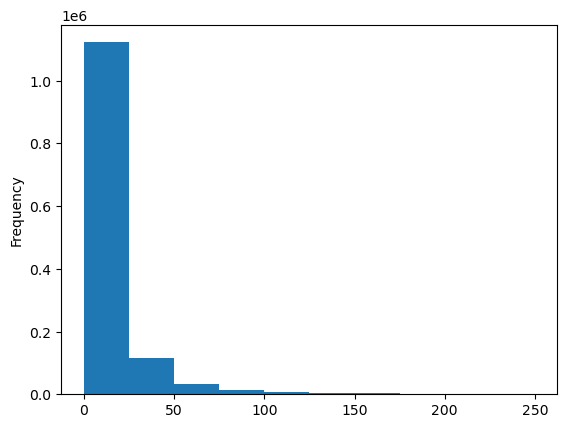

In [60]:
buildings_linked[buildings_linked['hh_gencap_opflex'] < 250]['hh_gencap_opflex'].plot(kind = "hist")

<Axes: ylabel='Frequency'>

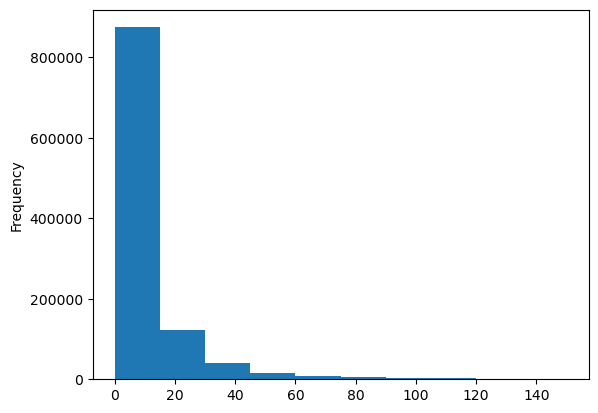

In [64]:
buildings_linked[buildings_linked['hh_gencap_pv'] < 150]['hh_gencap_pv'].plot(kind = "hist")